healpix map:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
healpix map:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
healpix map:
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
healpix map:
 [0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
healpix map:
 [0. 0. 2. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
healpix map:
 [0. 0. 2. 4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
healpix map:
 [0. 0. 2. 7. 0. 0. 0

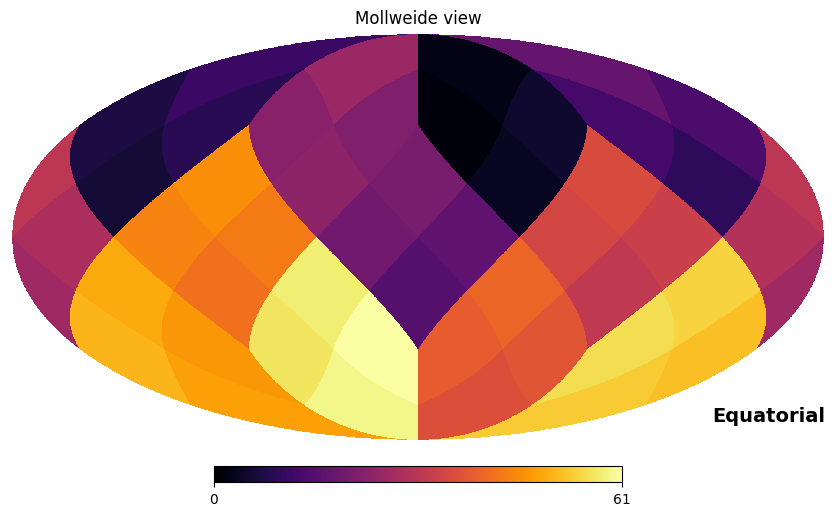

Number of zeros in the Healpix map: 0
number of pixels allocated from original:
 256
number of pixels in original map:
 256


In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# Create a 4X4 image array
array = np.arange( 8* 8).reshape(8, 8)
# Initialize constants
subdivision_rows = 2
subdivision_cols = 2

# Calculate the dimensions of the new array
new_rows = len(array) * subdivision_rows
new_cols = len(array[0]) * subdivision_cols

# Initialize the new array with zeros
image_array = np.zeros((new_rows, new_cols), dtype=array.dtype)

# Iterate through each element in the original array
for i in range(len(array)):
    for j in range(len(array[0])):
        original_element = array[i][j]
        
        # Fill the subdivisions with the original element value
        for x in range(subdivision_rows):
            for y in range(subdivision_cols):
                image_array[i * subdivision_rows + x][j * subdivision_cols + y] = original_element

# Set angular resolution
# Define the spherical coordinates
theta = np.linspace(0, np.pi, num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.pi, np.pi, num=image_array.shape[1],endpoint=False)

# Set angular resolution
nside = 2

## Make empty healpix mask and pixel values vector
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)
for i in range(len(theta)):
    for j in range(len(phi)):
        pixel=hp.ang2pix(nside,theta[i],phi[j])
        healpix_map[pixel]+=image_array[i,j]
        pixel_counts[pixel]+=1
        print(f"healpix map:\n {healpix_map}")
    
        

# Avoid division by zero
# Average and assign to HEALPix

healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0]




hp.mollview(healpix_map, cmap="inferno", xsize=3000, coord="C", flip="geo", norm="hist", min=0, nest=True)
plt.show()

zero_mask = healpix_map == 0
# Count the number of zeros
num_zeros = np.sum(zero_mask)

print(f"Number of zeros in the Healpix map: {num_zeros}")

print("number of pixels allocated from original:\n",np.sum(pixel_counts))
print("number of pixels in original map:\n",np.size(image_array))

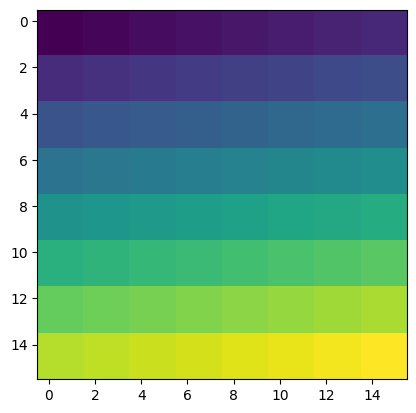

In [4]:
plt.imshow(image_array)

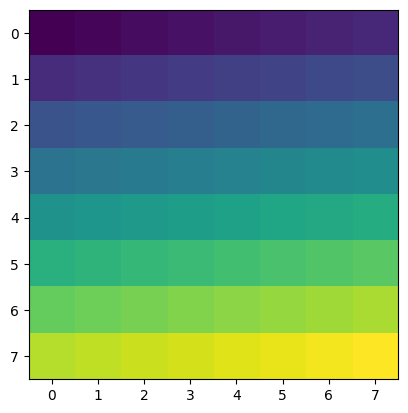

In [5]:
plt.imshow(array)